In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from nflows.transforms.normalization import ActNorm
from tqdm import tqdm

from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.inverse_problems.riemannian_ambient_flow import RiemannianAmbientFlowProblem
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.riemannian_autoencoder.image.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackImageRiemannianAutoencoder
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

# Experiment settings
folder_name = "mnist_inpainting_h28_w28_mask0.7_noise0.1_pgd_stepsize[0.99]_g[0.4]_sigma[0.99]_maxiter10"
data_folder_path = os.path.join("data","MNIST","reconstructed",f"{folder_name}")
results_folder_path = os.path.join("results","mnist","raf",f"{folder_name}")

In [2]:
# Plot original, noisy, and denoised images
def show_images(img_list, titles):
    fig, axes = plt.subplots(1, len(img_list), figsize=(12, 4))
    for i, (img, title) in enumerate(zip(img_list, titles)):
        axes[i].imshow(img[0].cpu().numpy().squeeze(), cmap="gray")
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_187857/1219290346.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chunk = torch.load(os.path.join(data_folder_path, file))


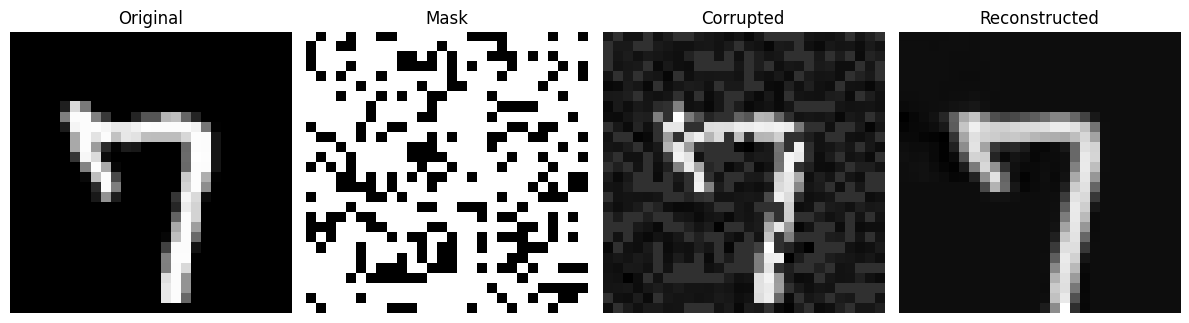

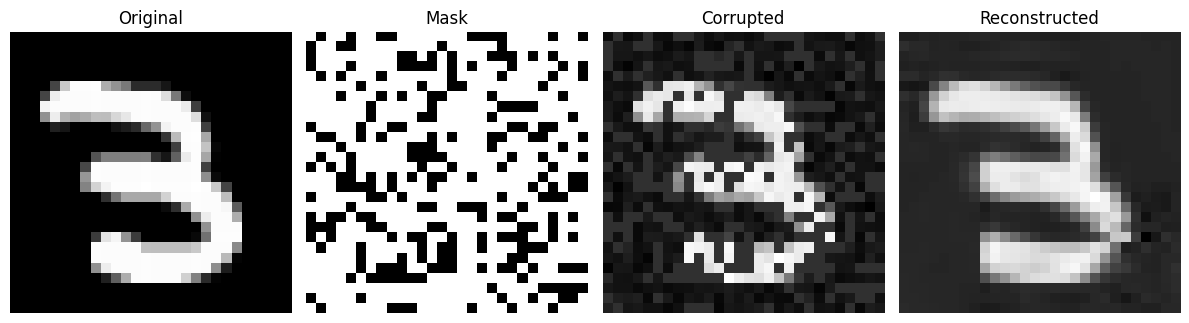

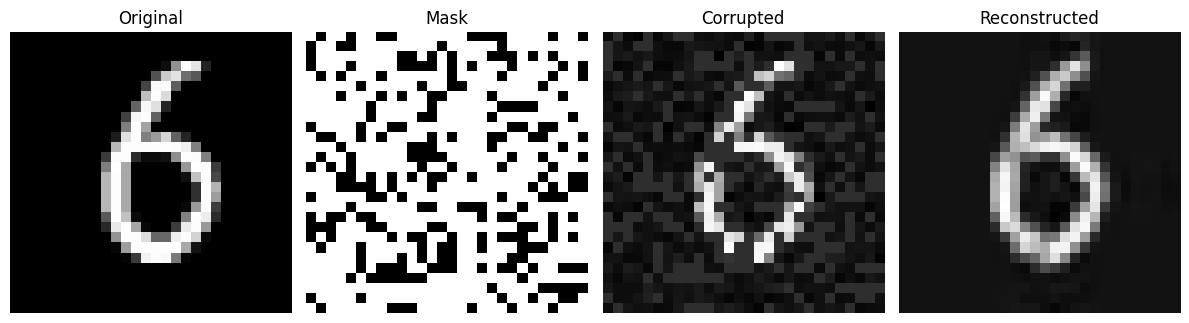

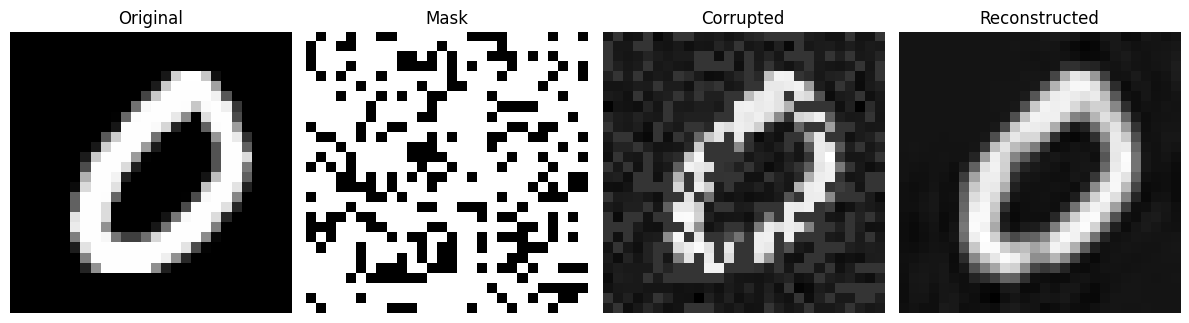

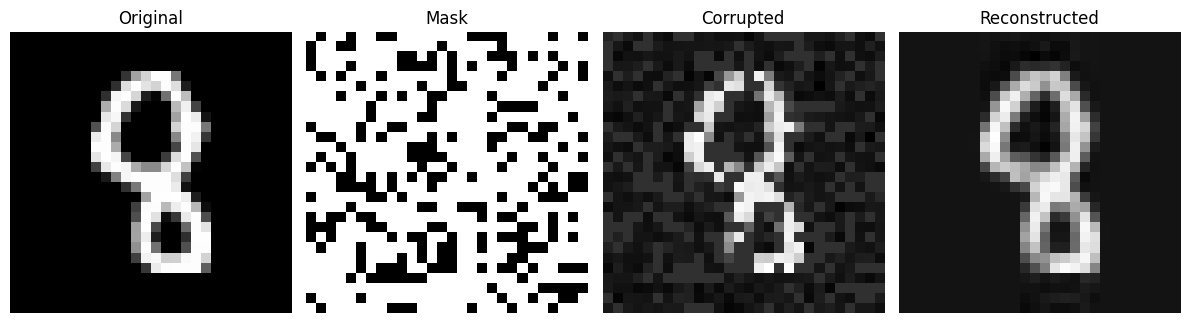

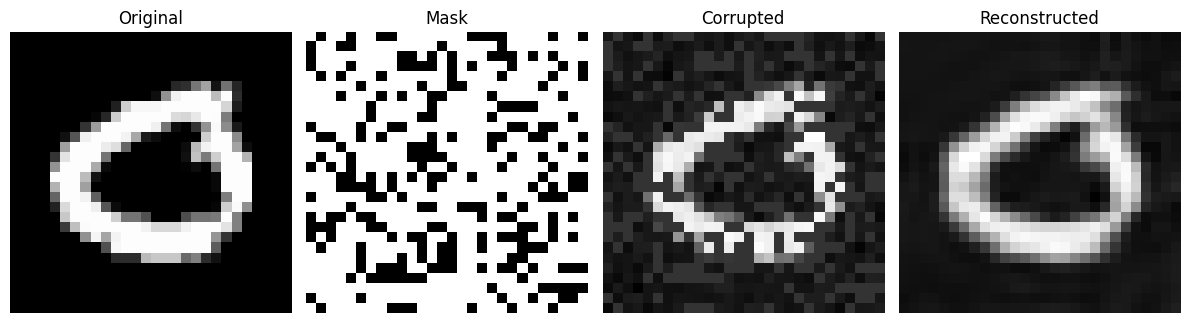

In [ ]:
# load train data set
num_denoised_train = 256
num_corrupted_train = 8192
num_train = num_corrupted_train + num_denoised_train
H, W = 28,28

# load training data chunks
chunk_files_train = sorted([f for f in os.listdir(data_folder_path) if f.startswith("mnist_inpainting_pnp_train")])

all_cor_data_train = []
all_rec_data_train = []
all_clean_data_train = []
all_start_idx_train = []

for file in chunk_files_train:
    if int(file.split('_')[-2]) < num_train:
        chunk = torch.load(os.path.join(data_folder_path, file))
        all_cor_data_train.append(chunk['cor_data'])
        all_rec_data_train.append(chunk['rec_data'])
        all_clean_data_train.append(chunk['clean_data'])
        all_start_idx_train.append(chunk['end_index'] + 1)

# ensure we have enough training data
start_idx_ckpt = max(all_start_idx_train)
assert start_idx_ckpt >= num_train, "not enough training data available!"

# extract mask from one of the chunks
mask = chunk['mask']

# concatenate all training data chunks
cor_data_train_ckpt = torch.cat(all_cor_data_train, dim=0)
rec_data_train_ckpt = torch.cat(all_rec_data_train, dim=0)
clean_data_train_ckpt = torch.cat(all_clean_data_train, dim=0)

# extract training data
cor_data_train_labeled = cor_data_train_ckpt[:num_denoised_train]
cor_data_train = cor_data_train_ckpt[num_denoised_train:num_train]
rec_data_train_labeled = rec_data_train_ckpt[:num_denoised_train] 
clean_data_train_labeled = clean_data_train_ckpt[:num_denoised_train] # not used for training, only for visualization

# construct train loader from cor_data_train and rec_data_train
batch_size = 64
labeled_train_dataset = torch.utils.data.TensorDataset(cor_data_train_labeled, rec_data_train_labeled)
labeled_train_loader = torch.utils.data.DataLoader(labeled_train_dataset, batch_size=batch_size, shuffle=True)

unlabeled_train_dataset = torch.utils.data.TensorDataset(cor_data_train)
unlabeled_train_loader = torch.utils.data.DataLoader(unlabeled_train_dataset, batch_size=batch_size, shuffle=True)

# Show original, mask, corrupted, and reconstructed images
for i in range(6):
    show_images(
            [clean_data_train_labeled[i], mask, cor_data_train[i], rec_data_train_labeled[i]],
            ["Original", "Mask", "Corrupted", "Reconstructed"]
        )

### Learning Pullback Geometry ###

In [4]:
# define physics operator
class MaskedForward(nn.Module):
    def __init__(self, mask, pseudo_inverse_reg=None):
        super().__init__()
        self.mask = mask
        self.lambd = pseudo_inverse_reg
    
    def forward(self, x):
        return self.mask.to(x.device) * x
    
    def pseudo_inverse(self, y):
        if self.lambd is not None:
            return 1 / (1 + self.lambd) * self.mask.to(y.device) * y
        else:
            return self.mask.to(y.device) * y

In [5]:
# define the normalizing flow model
def create_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    base_dist = distributions.StandardNormal(shape=[in_channels, height, width])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return NFlowImageDiffeomorphism(1, height, width, flows.Flow(transform=flow_transforms, distribution=base_dist))

In [ ]:
# define context encoder
class CNN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        layers = []
        layers.append(nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(hidden_channels, in_channels, kernel_size=3, padding=1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
class UnrolledNN(nn.Module): # TODO: use deepinv or other library to implement unrolled NN + consider using something pretrained or pretrain some network in this notebook before using it here
    def __init__(self):
        super().__init__()
        # @OSCAR: implement unrolled neural network here that maps the input corrupted image to a reconstructed version

    def forward(self, x):
        # @OSCAR: implement forward pass of unrolled neural network here
        pass

class DualOutputNet(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        self.unrolled_nn = None # @OSCAR: implement unrolled neural network here that maps the input corrupted image to a reconstructed version
        self.cnn = CNN(in_channels, hidden_channels)

    def forward(self, x):
        unrolled_out = self.unrolled_nn(x)
        cnn_out = self.cnn(unrolled_out)
        out = torch.cat([unrolled_out, cnn_out], dim=-1)  # concatenate along channel dimension
        return out

In [7]:
# define the conditional normalizing flow model
def create_conditional_distribution_model(in_channels, height, width, hidden_channels):
    context_encoder = DualOutputNet(in_channels, hidden_channels)
    return distributions.ConditionalDiagonalNormal(shape=[in_channels, height, width], context_encoder=context_encoder)

In [ ]:
# initialize the model
forward = MaskedForward(mask)

L = 64
K = 5
order = 2
n_flows = 3
prior_nflow_diffeo = create_flow_model(1, H, W, K, L, order, n_flows)

M = 16
posterior_dist = create_conditional_distribution_model(1, H, W, M)

noise_level = 0.1
low_rank_reg_param = None # @OSCAR: this seems to be broken in the current implementation for images
clean_data_reg_param = 0.1 # @OSCAR: set appropriate regularization parameter here
model = RiemannianAmbientFlowProblem(forward, prior_nflow_diffeo, posterior_dist, noise_level, low_rank_reg_param=low_rank_reg_param, clean_data_reg_param=clean_data_reg_param).to(device)

lr = 1e-2
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
# Training loop
def train(model, labeled_train_loader, unlabeled_train_loader, optimizer, n_epochs, save_dir, start_epoch=0):
    best_loss = float('inf')

    for epoch in range(start_epoch, n_epochs):
        model.train()
        epoch_loss = 0
        for y, x_y in tqdm(labeled_train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"): #@OSCAR: integragte loop for unlabeled data as well 
            optimizer.zero_grad()
            
            y = y.to(device)
            x_y = x_y.to(device)
            # Compute loss
            loss = model.reconstruction_loss(y, x=x_y)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        # Calculate average loss for the epoch
        avg_epoch_loss = epoch_loss / len(train_loader) #@OSCAR: integragte loop for unlabeled data as well/make sure that this makes sense
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'best_loss': best_loss,
        }
        
        if (epoch + 1) % 5 == 0:
            print("saving checkpoint...")
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [ ]:
# Train the model
n_epochs = 100
checkpoint_dir = os.path.join(results_folder_path, f"checkpoints_latent_dim{L}_kernel_size{K}_order{order}_n_flows{n_flows}_ntrain[{num_train}]_lr[{lr}]")
if low_rank_reg_param is not None:
    checkpoint_dir += f"_lowrankreg[{low_rank_reg_param}]"
os.makedirs(checkpoint_dir, exist_ok=True)
print(checkpoint_dir)

# Train or load model
train_model = True
if train_model:
    start_epoch = 0
    best_loss = float('inf')

    # Check if there's a checkpoint to resume from
    latest_checkpoints = [f for f in os.listdir(checkpoint_dir) if f.startswith("epoch")]
    if latest_checkpoints:
        latest_checkpoint = max(latest_checkpoints, key=lambda x: int(x.split('_')[1]))
    else:
        latest_checkpoint = None    
    print(latest_checkpoint)
    
    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(os.path.join(checkpoint_dir, latest_checkpoint))
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']

    train(model, labeled_train_loader, unlabeled_train_loader, optimizer, n_epochs, checkpoint_dir, start_epoch=start_epoch)
else:
    # best_model_path = os.path.join(checkpoint_dir, 'epoch_200_model.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()

results/mnist/pnp_raf/mnist_inpainting_h28_w28_mask0.7_noise0.1_pgd_stepsize[0.99]_g[0.4]_sigma[0.99]_maxiter10/checkpoints_latent_dim64_kernel_size5_order2_n_flows3_ntrain[1024]_lr[0.01]
epoch_100_model.pth
Resuming training from epoch_100_model.pth
Training completed. Best model saved with loss: inf


/tmp/ipykernel_187857/1001207982.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(checkpoint_dir, latest_checkpoint))


PnPRiemannianAmbientFlowProblem(
  (forward_operator): MaskedForward()
  (phi_prior): NFlowImageDiffeomorphism(
    (nflow): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): ActNorm()
          (1-2): 2 x ParityConv2DTransform(
            (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
          )
          (3): MultiLayerTanhParityConv2DTransform(
            (cnn): Sequential(
              (0): MaskedConv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
              (1): TanhActivation()
              (2): MaskedConv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
              (3): TanhActivation()
              (4): MaskedConv2d(64, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            )
          )
          (4): ActNorm()
          (5-6): 2 x ParityConv2DTransform(
            (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=Fal

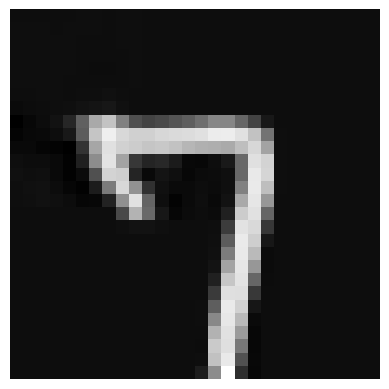

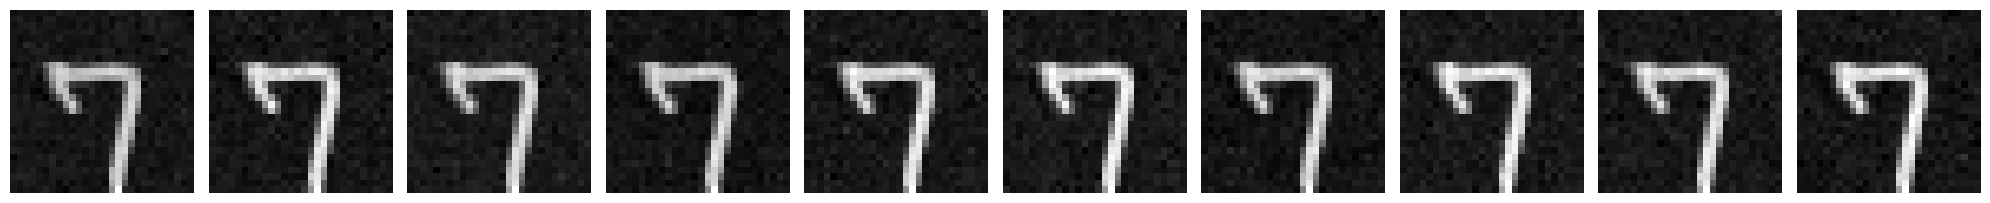

In [ ]:
# sample posterior distribution
x_reconstructed = model.p_post.sample(10, context=rec_data_train_labeled[0][None].to(device))[0].detach()

# plot rec_data_train[0] and x_reconstructed[0]
plt.imshow(rec_data_train_labeled[0].cpu().squeeze(), cmap="gray")
plt.axis("off")
plt.show()

# plot reconstructed samples
fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    axes[i].imshow(x_reconstructed[i].cpu().squeeze(), cmap="gray")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

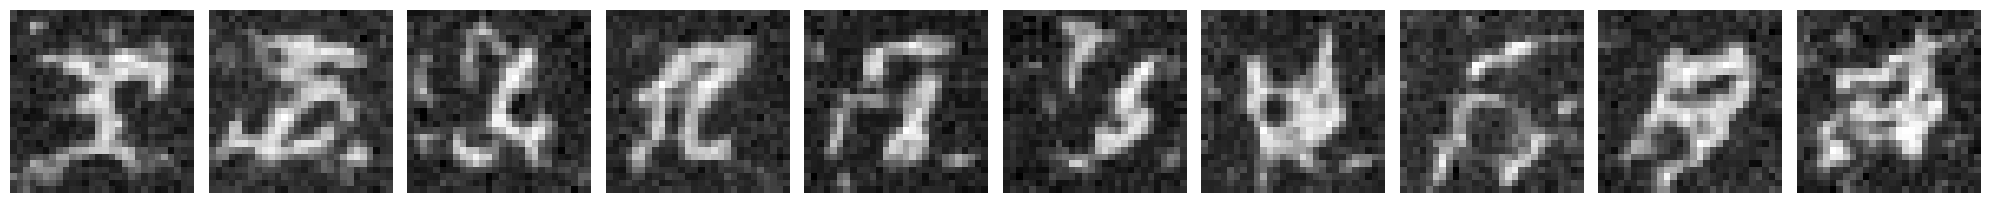

In [12]:
# sample prior distribution
x_prior_samples = model.phi_prior.nflow.sample(10).detach()

# plot prior samples
fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    axes[i].imshow(x_prior_samples[i].cpu().squeeze(), cmap="gray")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Evaluating Pullback Geometry ###

In [13]:
# construct manifold
manifold = StandardPullbackImageEuclidean(model.phi_prior)

In [ ]:
# compute geodesics
num_points = 10
num_geodesics = 5
t = torch.linspace(0., 1., num_points).to(device)

clean_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)

# generate geodesics
for i in range(num_geodesics):
    clean_geodesics[i] = manifold.geodesic(clean_data_train_labeled[i].to(device), clean_data_train_labeled[i+num_geodesics].to(device), t).detach().cpu()

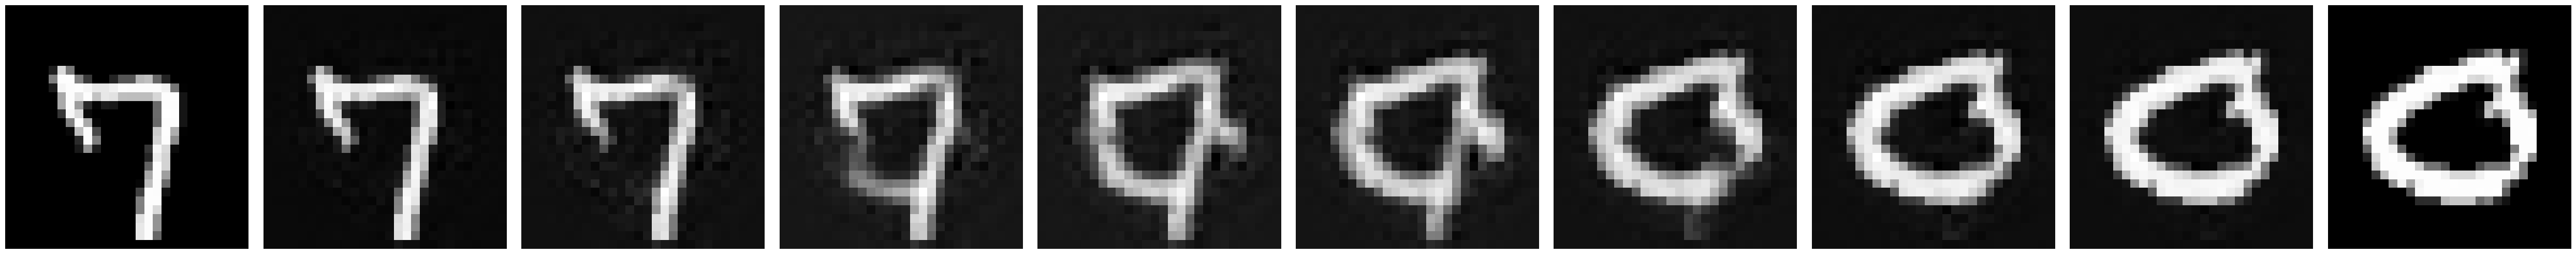

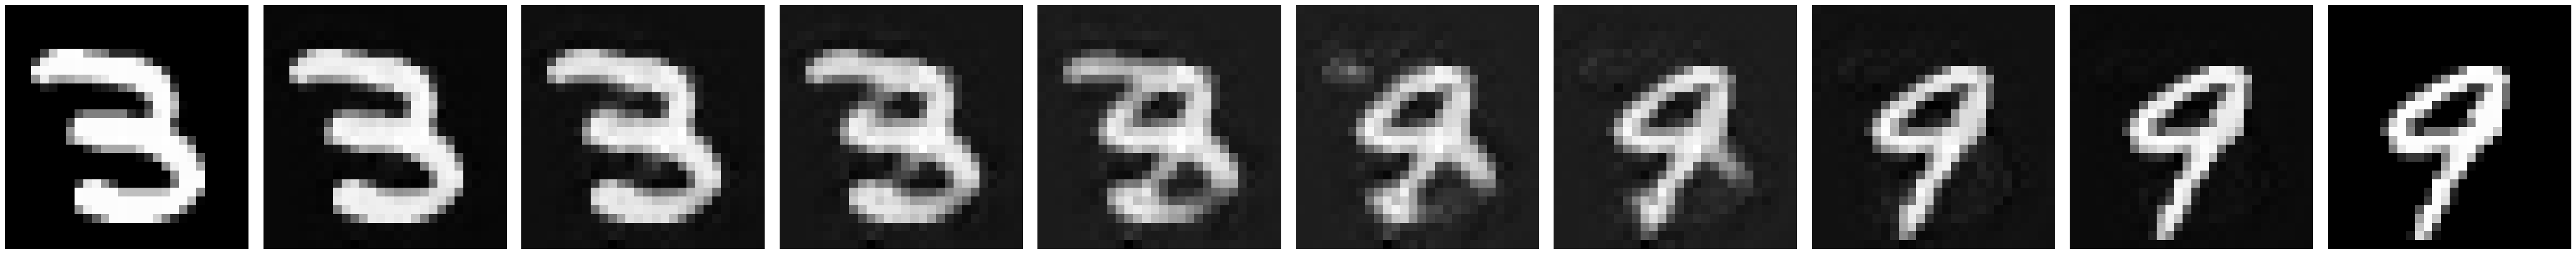

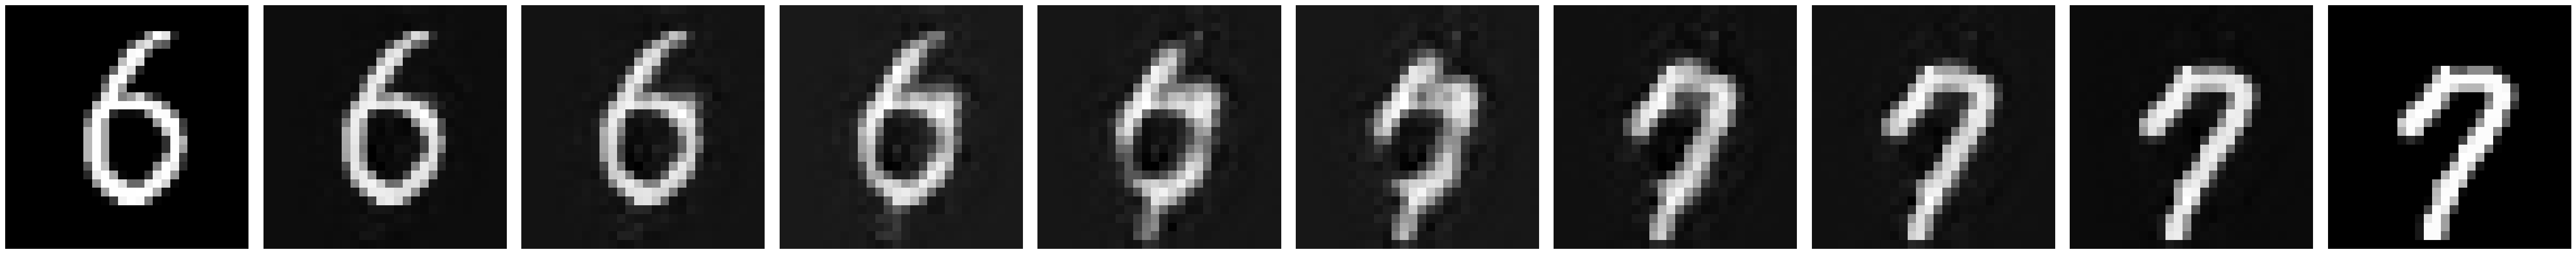

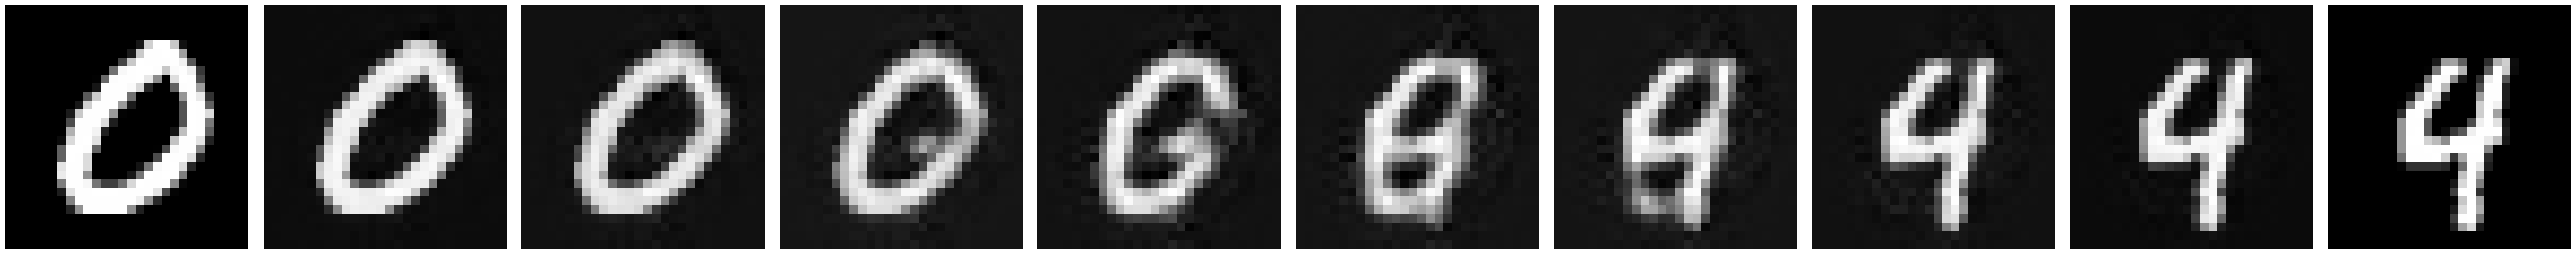

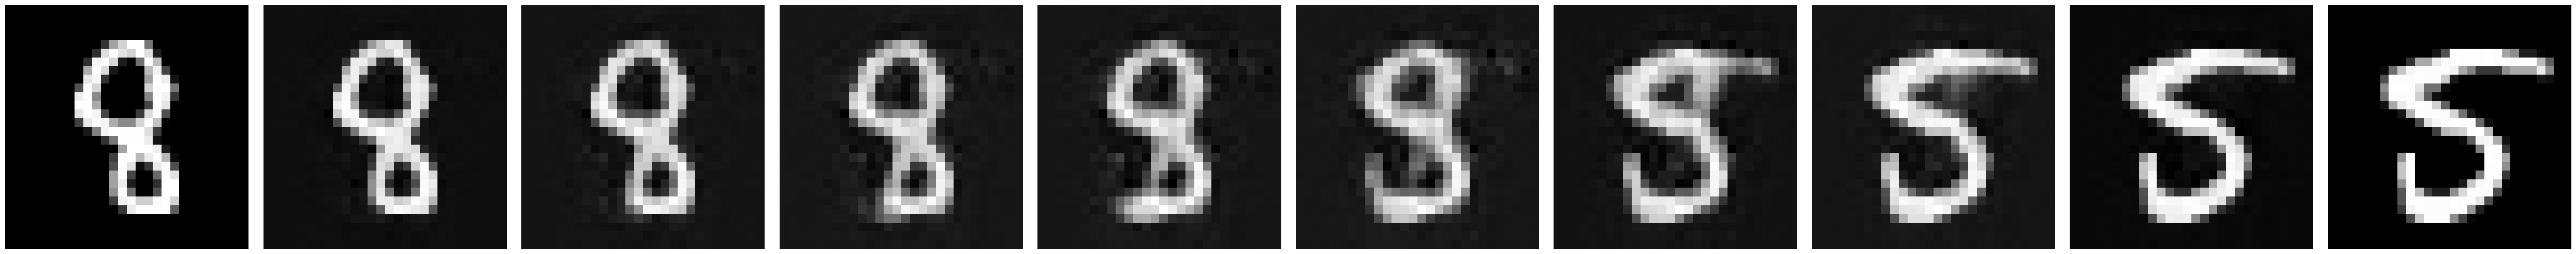

In [15]:
# plot each image in the grid
for i in range(num_geodesics):
    fig, axes = plt.subplots(1,num_points, figsize=(5*num_points, 5))
    for j in range(num_points):
        axes[j].imshow(clean_geodesics[i, j].squeeze(), cmap='gray')
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# compute barycentre
clean_bary = manifold.barycentre(clean_data_train_labeled.to(device)).detach().cpu()

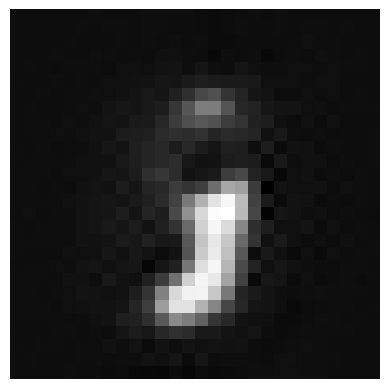

In [17]:
# plot barycentre
plt.imshow(clean_bary.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

### Construct RAE ###

In [ ]:
# construct base point for tangent space
rec_bary = manifold.barycentre(rec_data_train_labeled.to(device)).detach().cpu()

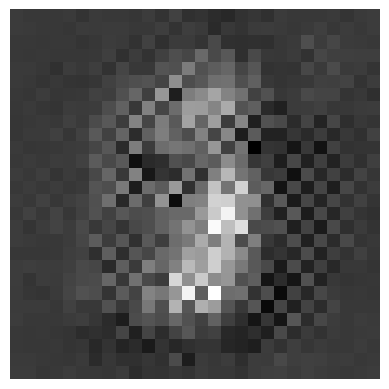

In [19]:
# plot barycentre
plt.imshow(rec_bary.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# construct RAE
latent_dim = 100
rae = l2TangentSpacePCAPullbackImageRiemannianAutoencoder(manifold, rec_data_train_labeled.to(device), latent_dim)
# rae = l2TangentSpacePCAPullbackImageRiemannianAutoencoder(manifold, rec_data_train.to(device), latent_dim, base_point=rec_data_train[6].to(device))

constructed a Riemannian autoencoder with latent dimension = 100 and effectice eps = 0.4531543254852295


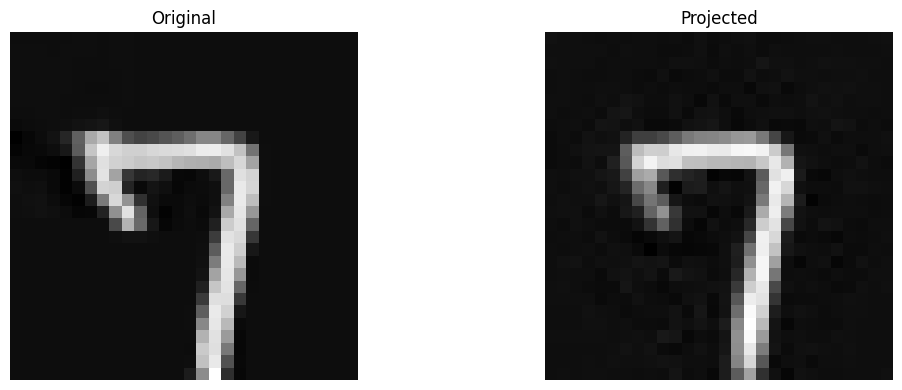

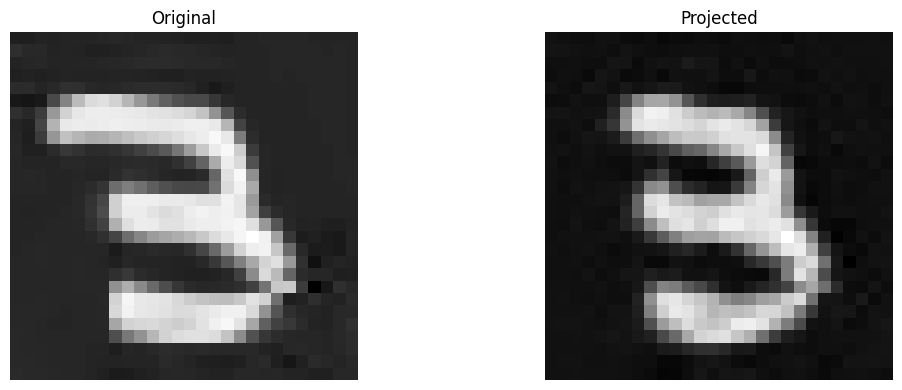

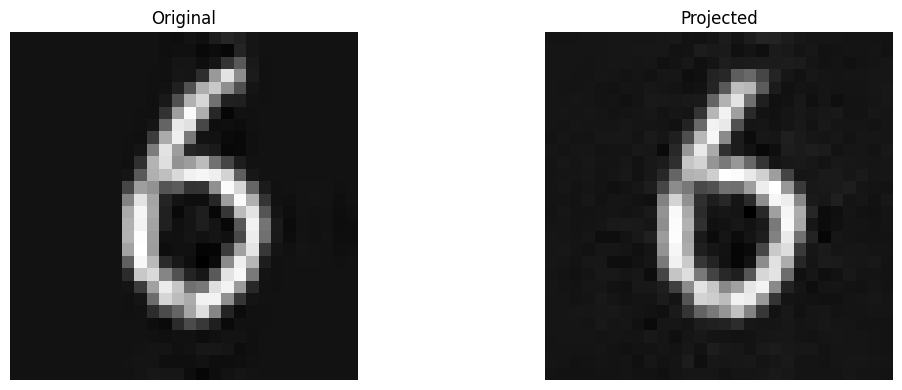

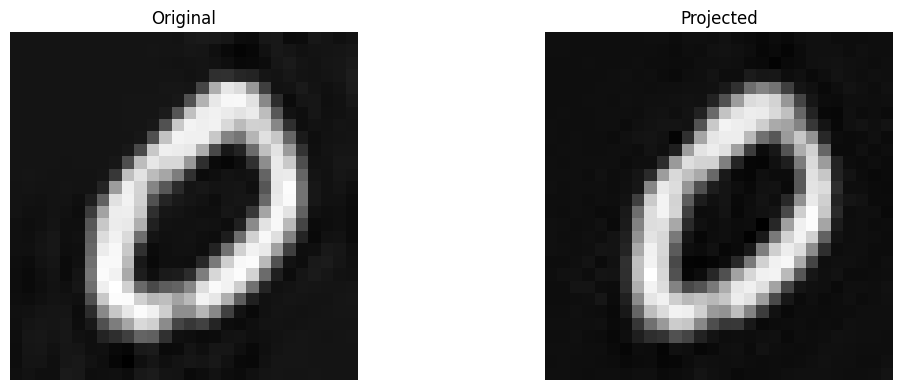

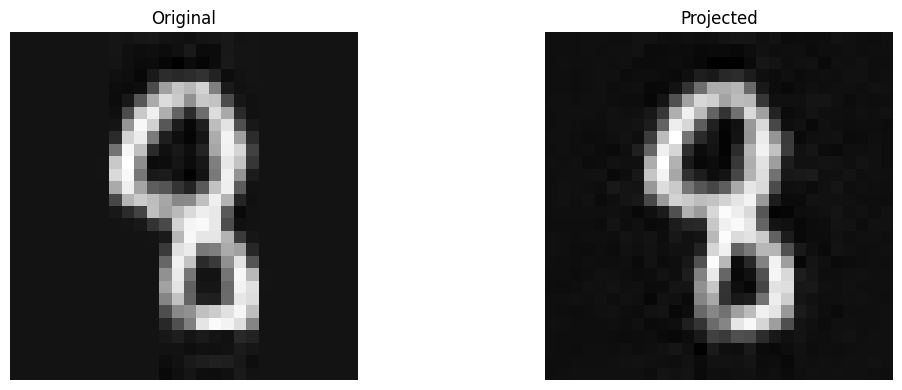

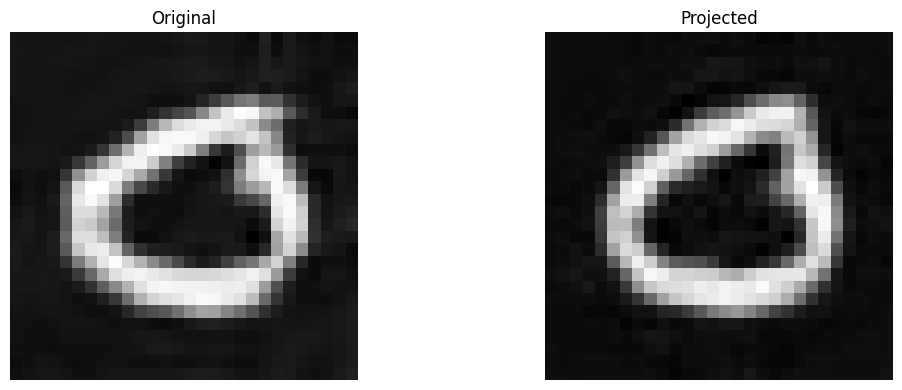

In [ ]:
# test RAE
projections = rae.project_on_manifold(rec_data_train_labeled.to(device)[:6]).detach().cpu()

# plot original and projected images
for i in range(6):
    show_images(
        [rec_data_train_labeled[i], projections[i].cpu()],
        ["Original", "Projected"]
    )

### Reconstruct over a Learned Data Manifold ###

/tmp/ipykernel_187857/2001898993.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chunk = torch.load(os.path.join(data_folder_path, file))


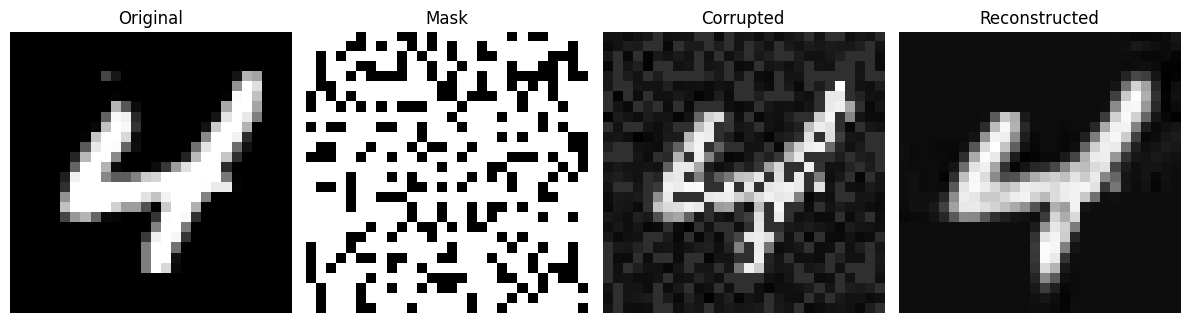

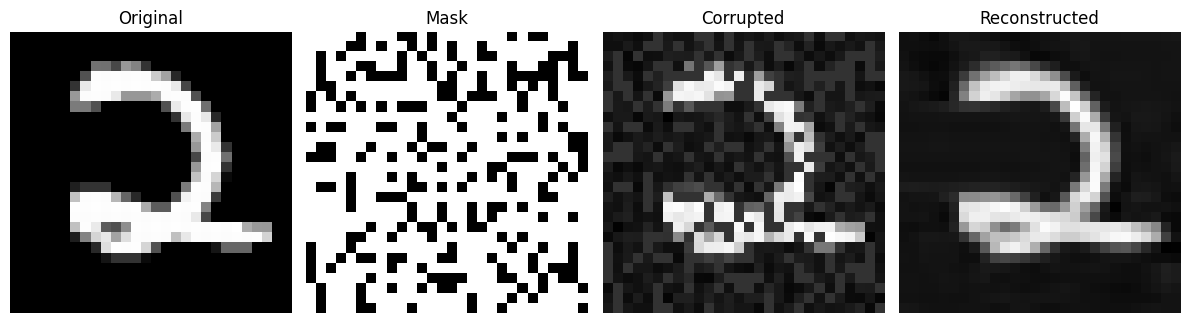

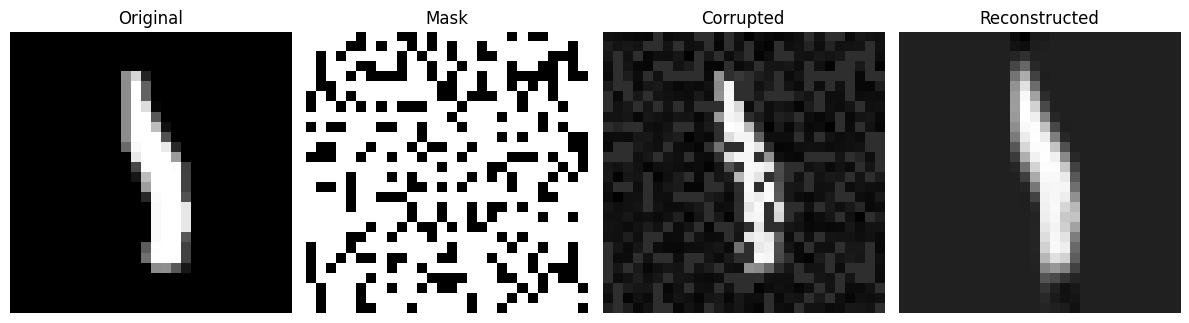

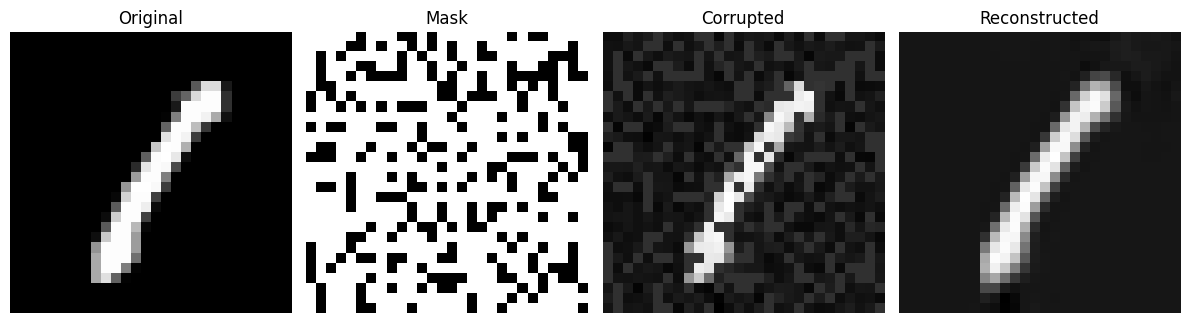

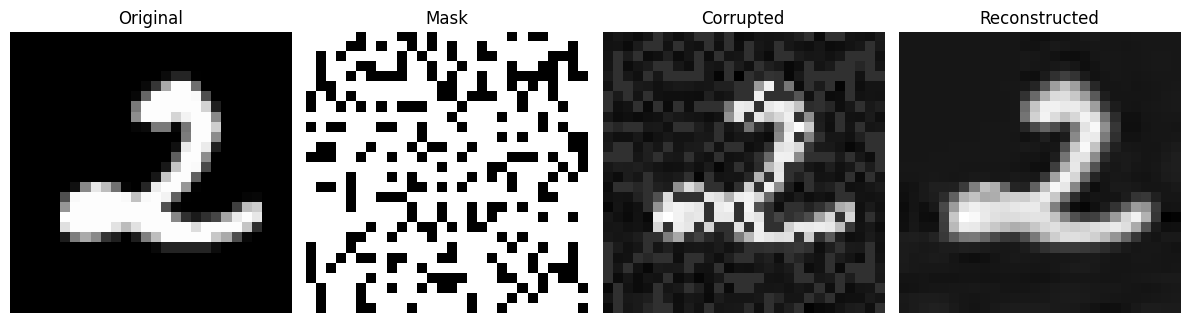

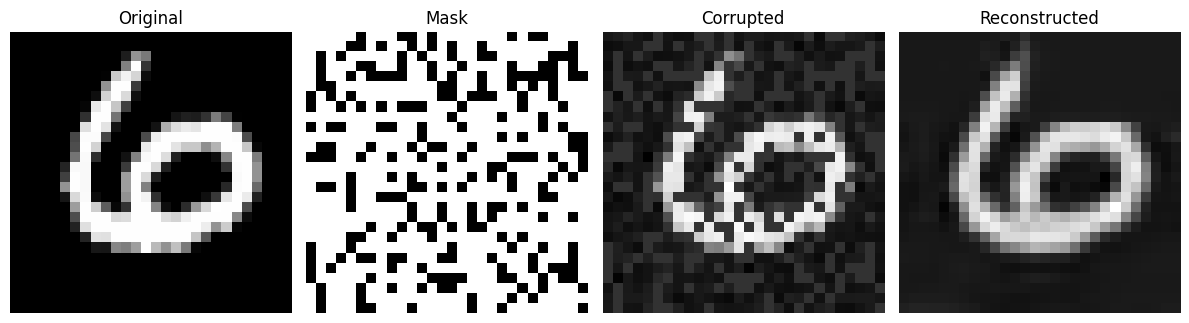

In [22]:
# load validation data set
num_val = 16
H, W = 28,28

# load validation data chunks
chunk_files_val = sorted([f for f in os.listdir(data_folder_path) if f.startswith("mnist_inpainting_pnp_val")])

all_cor_data_val = []
all_rec_data_val = []
all_clean_data_val = []
all_start_idx_val = []

for file in chunk_files_val:
    if int(file.split('_')[-2]) < num_val:
        chunk = torch.load(os.path.join(data_folder_path, file))
        all_cor_data_val.append(chunk['cor_data'])
        all_rec_data_val.append(chunk['rec_data'])
        all_clean_data_val.append(chunk['clean_data'])
        all_start_idx_val.append(chunk['end_index'] + 1)

# ensure we have enough validation data
start_idx_ckpt = max(all_start_idx_val)
assert start_idx_ckpt >= num_val, "not enough validation data available!"

# extract mask from one of the chunks
mask = chunk['mask']

# concatenate all validation data chunks
cor_data_val_ckpt = torch.cat(all_cor_data_val, dim=0)
rec_data_val_ckpt = torch.cat(all_rec_data_val, dim=0)
clean_data_val_ckpt = torch.cat(all_clean_data_val, dim=0)

# extract validation data
cor_data_val = cor_data_val_ckpt[:num_val]
rec_data_val = rec_data_val_ckpt[:num_val]
clean_data_val = clean_data_val_ckpt[:num_val]

# Show original, mask, corrupted, and reconstructed images
for i in range(6):
    show_images(
            [clean_data_val[i], mask, cor_data_val[i], rec_data_val[i]],
            ["Original", "Mask", "Corrupted", "Reconstructed"]
        )

Validation sample 1/16, Loss: 0.3805


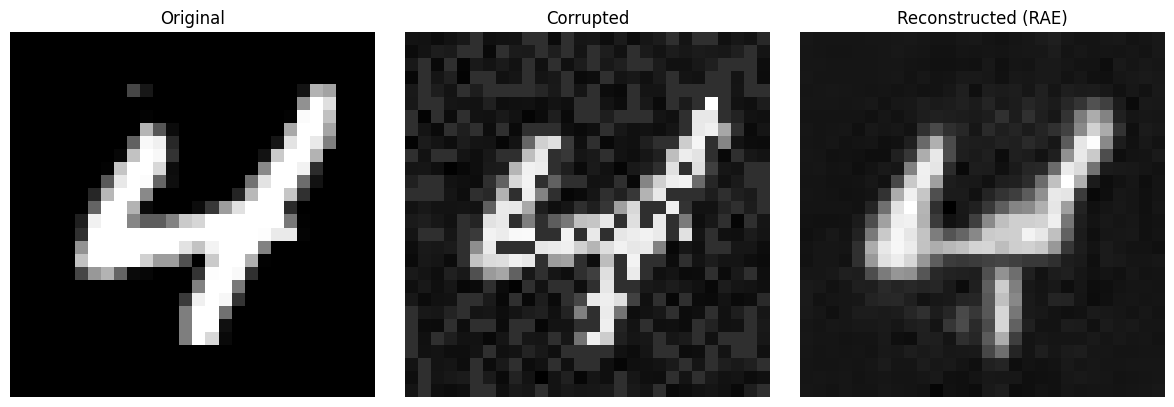

Validation sample 2/16, Loss: 0.4805


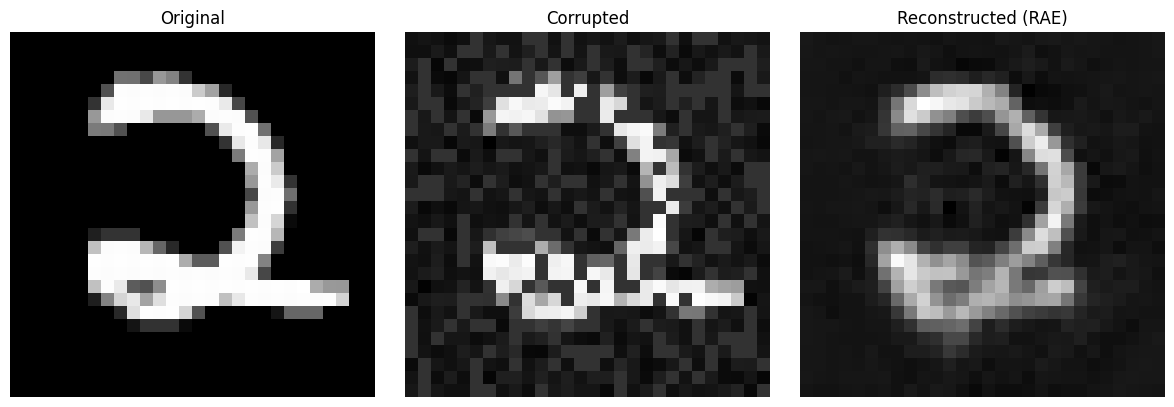

Validation sample 3/16, Loss: 0.2379


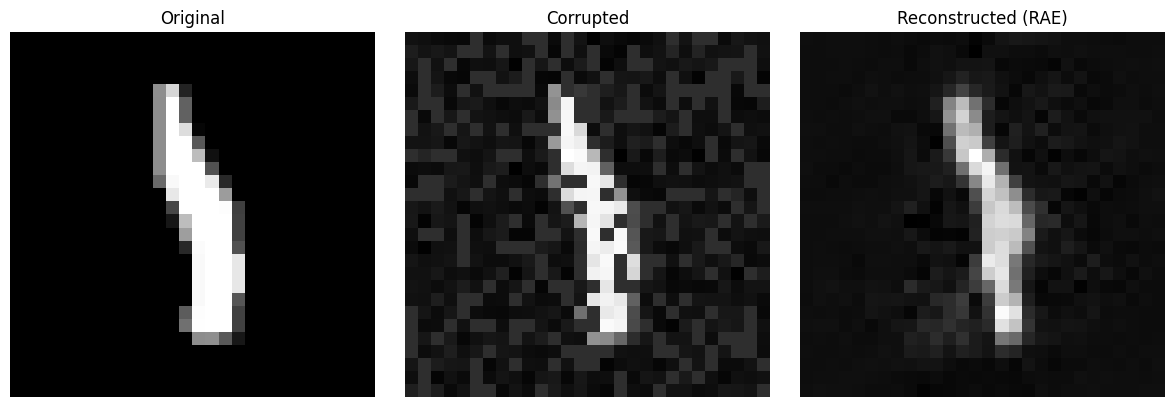

Validation sample 4/16, Loss: 0.2677


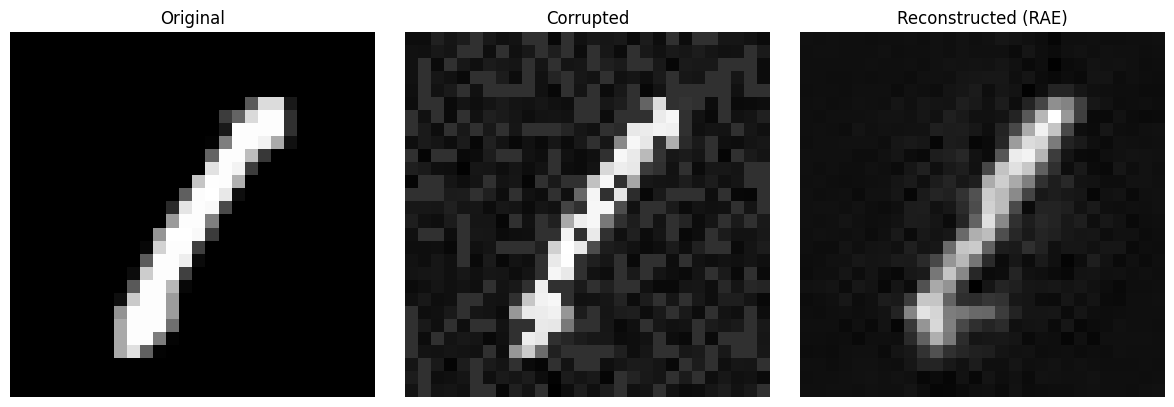

Validation sample 5/16, Loss: 0.3877


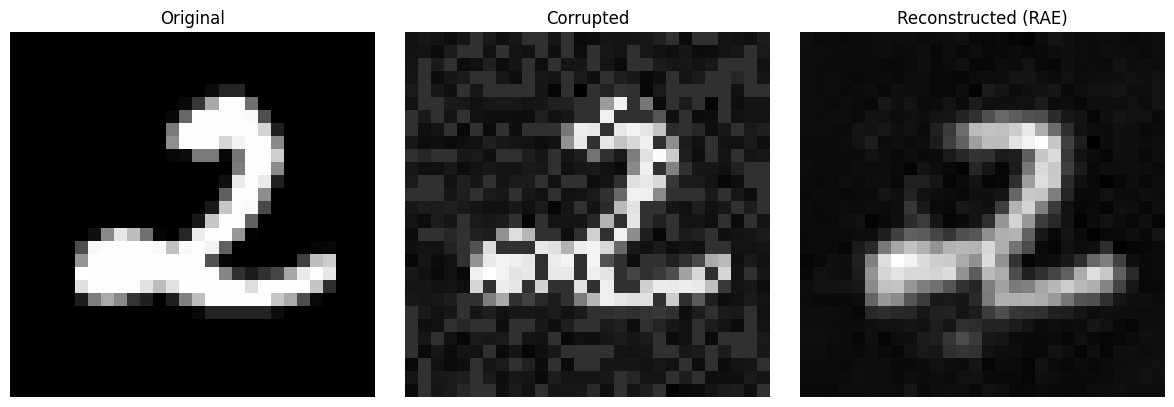

Validation sample 6/16, Loss: 0.5249


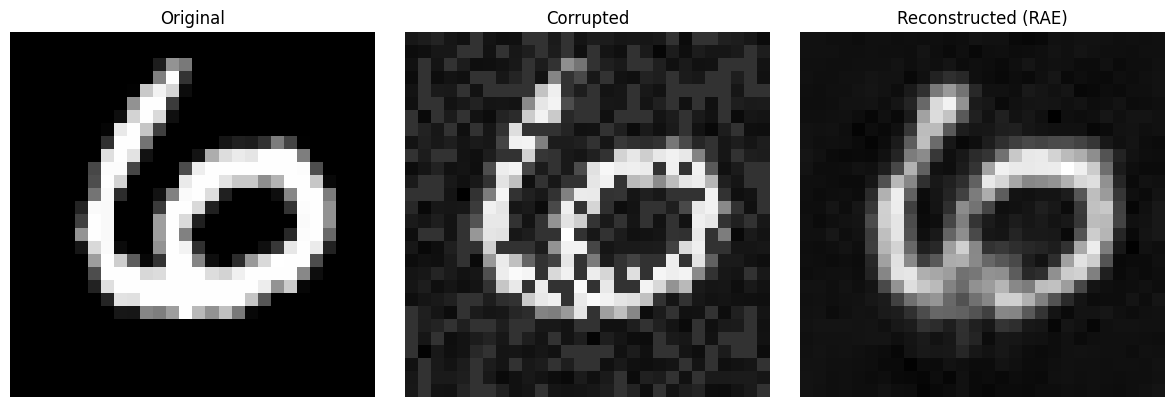

Validation sample 7/16, Loss: 0.1774


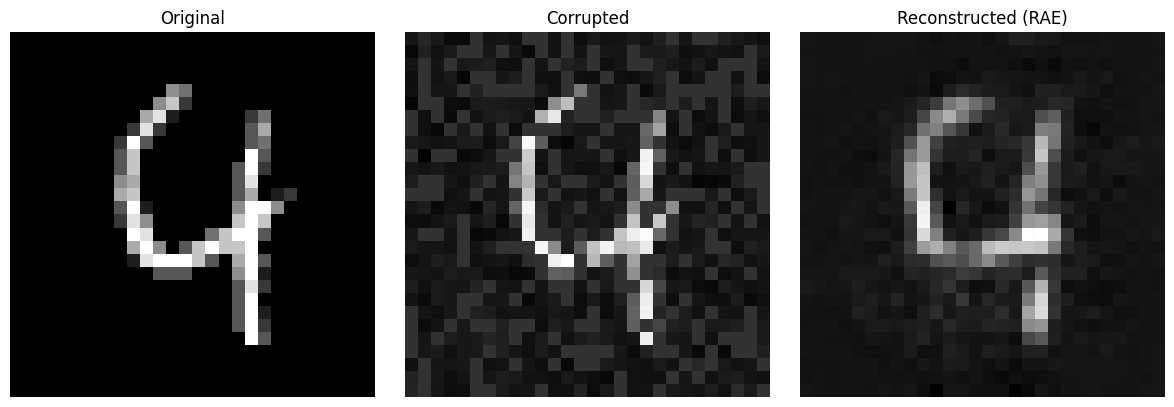

Validation sample 8/16, Loss: 0.3651


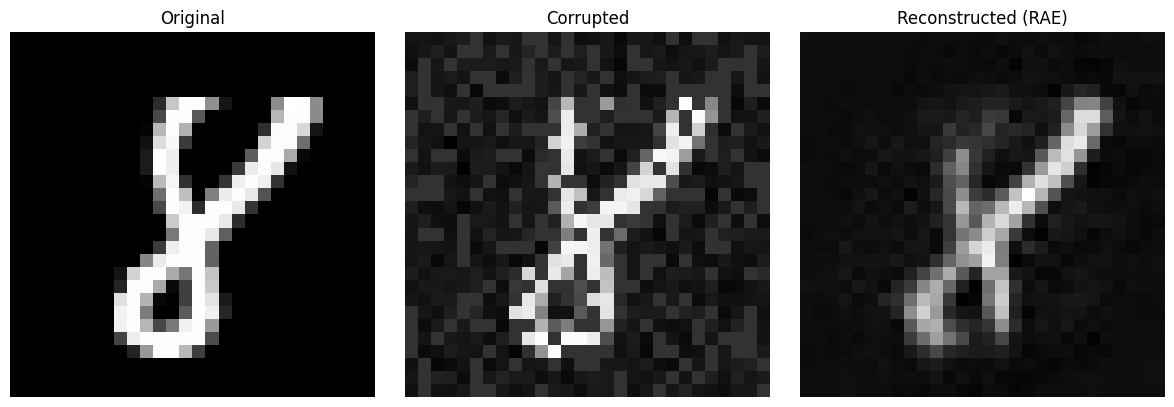

Validation sample 9/16, Loss: 0.4561


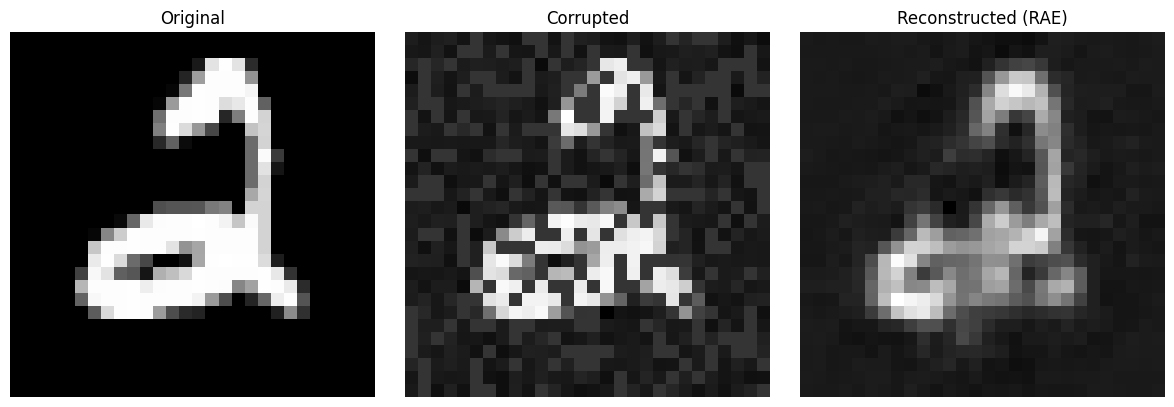

Validation sample 10/16, Loss: 0.2947


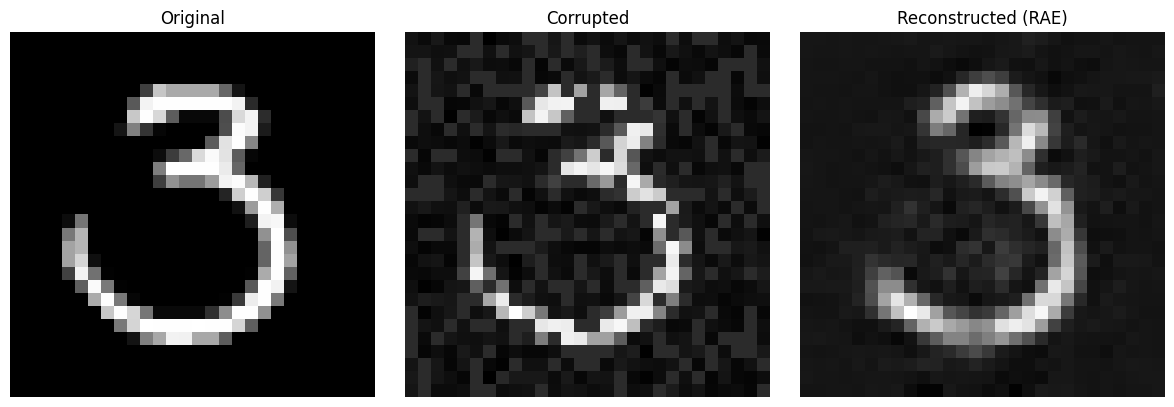

Validation sample 11/16, Loss: 0.3266


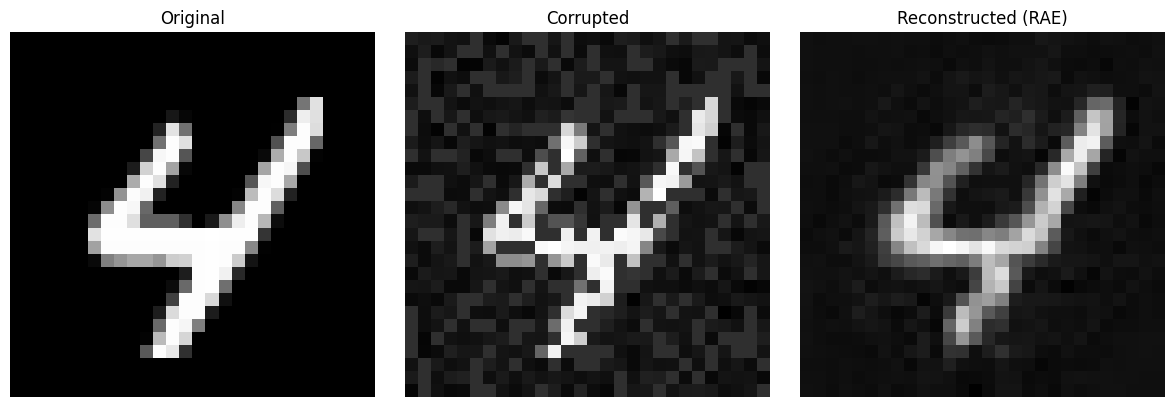

Validation sample 12/16, Loss: 0.3066


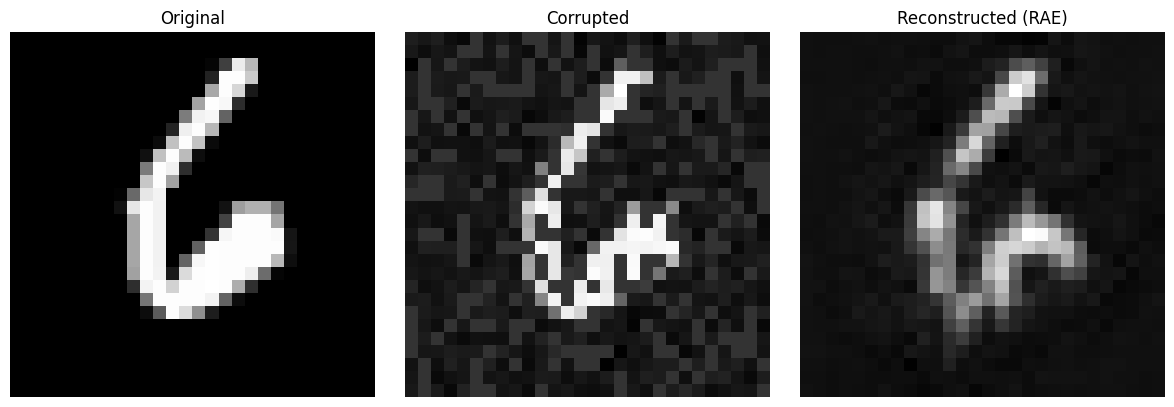

Validation sample 13/16, Loss: 0.2658


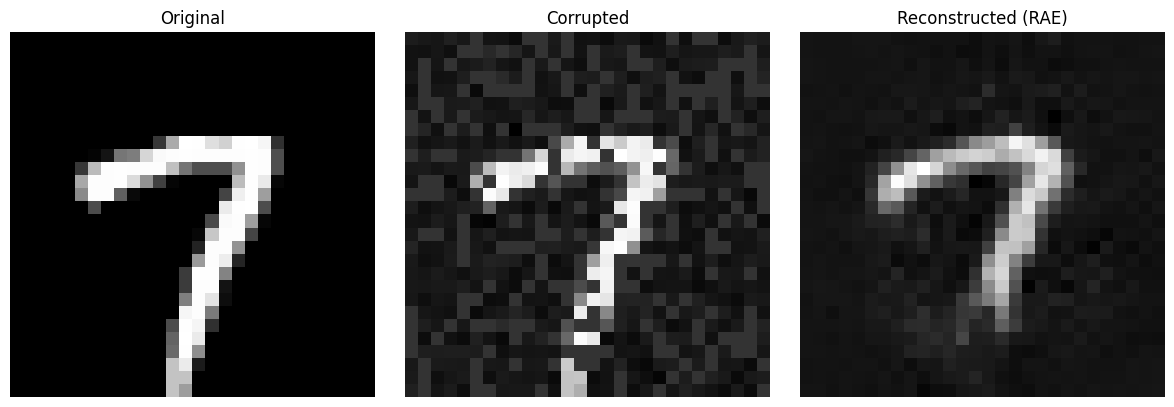

Validation sample 14/16, Loss: 0.2998


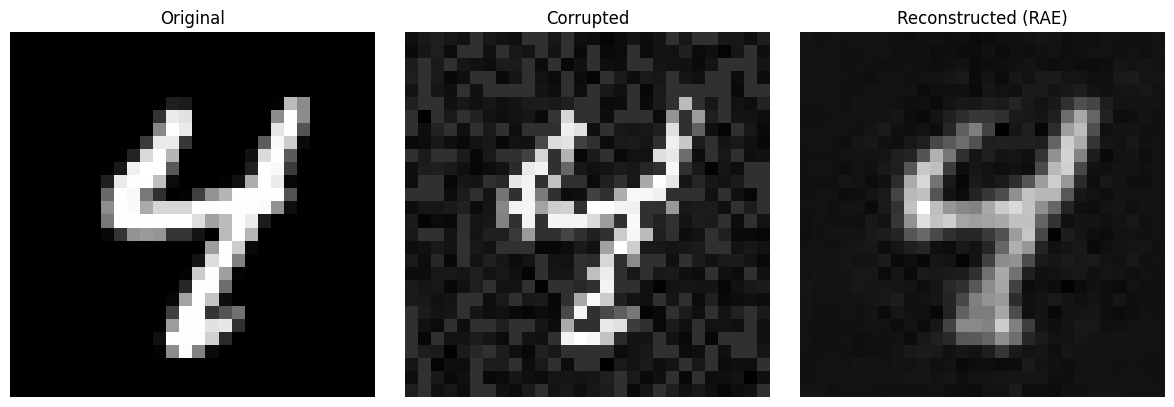

Validation sample 15/16, Loss: 0.3385


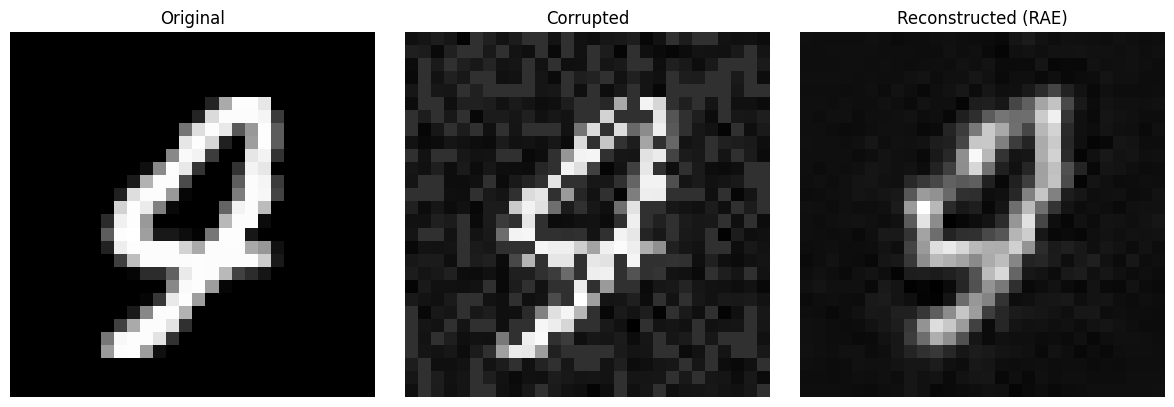

Validation sample 16/16, Loss: 0.4293


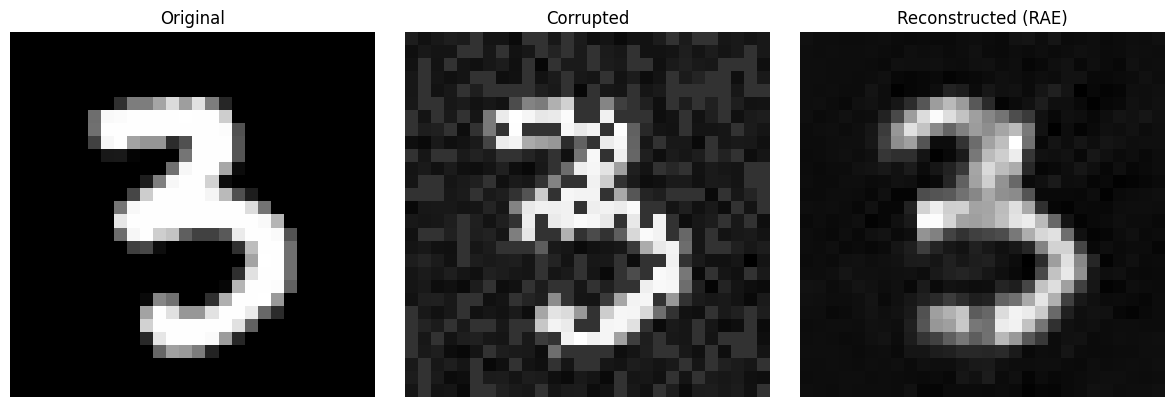

In [23]:
# solve inverse problem on validation data through optimization on the RAE latent space
num_iterations = 100
step_size = 1e-2
rec_rae_data_val = torch.zeros_like(rec_data_val)

# set up loss function
def loss_function(p, y):
    # map p through RAE decoder to get image
    x = rae.decode(p)
    # compute forward operation
    y_pred = forward(x)
    # compute loss
    return torch.nn.functional.mse_loss(y_pred, y)

# optimize for each validation data point
for i in range(num_val):
    p = torch.zeros((1, latent_dim), device=device, requires_grad=True)
    y = cor_data_val[i][None].to(device)
    optimizer_rae = optim.Adam([p], lr=step_size)
    for it in range(num_iterations):
        optimizer_rae.zero_grad()
        loss = loss_function(p, y)
        loss.backward()
        optimizer_rae.step()
    # decode optimized latent code to get reconstructed image
    rec_rae_data_val[i] = rae.decode(p).detach().cpu()
    print(f"Validation sample {i+1}/{num_val}, Loss: {loss.item():.4f}")
    # plot original, corrupted, reconstructed images
    show_images(
        [clean_data_val[i], cor_data_val[i], rec_rae_data_val[i]],
        ["Original", "Corrupted", "Reconstructed (RAE)"]
    )